In [ ]:
# Install or upgrade the 'langchain-google-genai' package quietly to its latest version.
# This package facilitates the integration of Google's Generative AI models with the LangChain framework.
pip install -qU langchain-google-genai

In [ ]:
import getpass # Imports the 'getpass' module, which provides a way to securely prompt for a password or sensitive information without echoing it to the console.
import os      # Imports the 'os' module, which provides a way of using operating system dependent functionality, like accessing environment variables.

# Checks if the "GOOGLE_API_KEY" environment variable is NOT set.
if not os.environ.get("GOOGLE_API_KEY"):
  # If the environment variable is not set, it prompts the user to enter their Google Gemini API key securely.
  # The entered key is then set as an environment variable for the current session.
  os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

# Imports the 'init_chat_model' function from the 'langchain.chat_models' module.
# This function is used to initialize a chat model instance from a specific provider.
from langchain.chat_models import init_chat_model

# Initializes a chat model instance.
# "gemini-2.0-flash" specifies the particular Gemini model to use (a fast, efficient version).
# "model_provider='google_genai'" indicates that the model is provided by Google's Generative AI service.
llm = init_chat_model("gemini-2.0-flash", model_provider="google_genai")

Enter API key for Google Gemini: ··········


In [ ]:
import getpass # Imports the 'getpass' module to securely prompt the user for input without echoing it to the console.
import os      # Imports the 'os' module to interact with the operating system, specifically to manage environment variables.

# Checks if the "GOOGLE_API_KEY" environment variable is not already set in the current environment.
if not os.environ.get("GOOGLE_API_KEY"):
  # If the "GOOGLE_API_KEY" environment variable is missing,
  # it prompts the user to securely enter their Google Gemini API key.
  # The entered key is then stored as an environment variable for the duration of the script's execution.
  os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

# Imports the 'GoogleGenerativeAIEmbeddings' class from the 'langchain_google_genai' library.
# This class is used to create embeddings (numerical representations) of text using Google's Generative AI models.
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Initializes an embedding model instance using Google's Generative AI.
# It specifies "models/embedding-001" as the particular pre-trained model to use for generating embeddings.
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")

In [ ]:
# Install or upgrade the 'langchain-core' package quietly to its latest version.
# 'langchain-core' contains the fundamental abstractions and building blocks
# for the entire LangChain ecosystem, providing core interfaces for
# language models, documents, embeddings, and more.
pip install -qU langchain-core

In [ ]:
# Imports the 'InMemoryVectorStore' class from the 'langchain_core.vectorstores' module.
# This class provides a simple, in-memory implementation of a vector store,
# which is used to store and retrieve vector embeddings (numerical representations of data).
from langchain_core.vectorstores import InMemoryVectorStore

# Initializes an instance of 'InMemoryVectorStore'.
# It takes the 'embeddings' object (presumably an instance of GoogleGenerativeAIEmbeddings initialized earlier)
# as an argument. This means the vector store will use this specific embedding model
# to convert text or other data into vectors before storing them.
vector_store = InMemoryVectorStore(embeddings)

In [ ]:
%%capture --no-stderr: This is a Jupyter Notebook specific magic command.
# It captures all standard output and standard error from the cell's execution,
# preventing it from being displayed in the notebook output.
# '--no-stderr' specifically tells it to only capture stderr (errors) but not display them either.

%pip install --upgrade --quiet langgraph langchain-community beautifulsoup4:
# This is another Jupyter Notebook specific magic command for installing Python packages.
# It's equivalent to running 'pip install' from the command line.
# --upgrade: Ensures that any already installed packages are upgraded to their latest versions.
# --quiet: Suppresses verbose output during the installation process, showing only essential information (like errors).
# langgraph: Installs the 'langgraph' library, which is used for building robust, stateful, and multi-actor applications with LLMs.
# langchain-community: Installs the 'langchain-community' package, which contains community-contributed integrations
#                      and utilities for LangChain (e.g., various document loaders, tools, vector stores, etc.).
# beautifulsoup4: Installs the 'beautifulsoup4' library, which is a Python library for parsing HTML and XML documents,
#                 often used for web scraping.

In [ ]:
# Sets the environment variable "LANGSMITH_TRACING" to "true".
# This enables tracing in LangChain applications, allowing you to visualize and debug
# the execution flow of your language model applications in LangSmith.
os.environ["LANGSMITH_TRACING"] = "true"

# Checks if the "LANGSMITH_API_KEY" environment variable is not already set.
if not os.environ.get("LANGSMITH_API_KEY"):
    # If the "LANGSMITH_API_KEY" environment variable is missing,
    # it prompts the user to securely enter their LangSmith API key.
    # The entered key is then stored as an environment variable for the duration of the script's execution,
    # enabling authentication with the LangSmith platform.
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass()

··········


In [ ]:
import bs4 # Imports the BeautifulSoup library for parsing HTML and XML documents.
from langchain import hub # Imports 'hub' from langchain, likely for loading pre-configured chains or prompts.
from langchain_community.document_loaders import WebBaseLoader # Imports 'WebBaseLoader' for loading documents from web pages.
from langchain_core.documents import Document # Imports the 'Document' class, a core data structure in LangChain for representing a piece of text and its associated metadata.
from langchain_text_splitters import RecursiveCharacterTextSplitter # Imports 'RecursiveCharacterTextSplitter' for splitting text into smaller, manageable chunks.
from typing_extensions import List, TypedDict # Imports 'List' and 'TypedDict' for type hinting, improving code readability and maintainability.

# Load and chunk contents of the blog

# Initializes a WebBaseLoader to load content from a specific URL.
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",), # Specifies the URL of the blog post to load.
    bs_kwargs=dict( # Provides additional keyword arguments to BeautifulSoup for parsing.
        parse_only=bs4.SoupStrainer( # Instructs BeautifulSoup to parse only specific HTML elements.
            class_=("post-content", "post-title", "post-header") # Specifies CSS classes of the elements to extract (main content, title, header).
        )
    ),
)
docs = loader.load() # Loads the content from the specified URL using the configured loader, resulting in a list of Document objects.

# Initializes a RecursiveCharacterTextSplitter for dividing the loaded documents into smaller chunks.
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200) # Sets chunk size to 1000 characters and an overlap of 200 characters between consecutive chunks.
all_splits = text_splitter.split_documents(docs) # Splits the loaded documents into smaller chunks based on the configured text splitter.

In [ ]:
# Indexes the processed document chunks into the previously initialized vector store.
# '_ = ' is used here to assign the return value (if any) to an unused variable,
# indicating that the return value of 'add_documents' is not needed for subsequent operations.
# 'vector_store' is an instance of InMemoryVectorStore (or a similar vector store)
# that uses an embedding model (like GoogleGenerativeAIEmbeddings) to convert
# the text chunks into numerical vectors before storing them for efficient similarity search.
# 'documents=all_splits' provides the list of Document objects (the text chunks from the blog post)
# to be added to the vector store.
_ = vector_store.add_documents(documents=all_splits)

In [ ]:
from langgraph.graph import MessagesState, StateGraph # Imports 'MessagesState' and 'StateGraph' from the 'langgraph.graph' module.
                                                    # 'MessagesState' is likely a predefined state type for graphs that operate on a sequence of messages.
                                                    # 'StateGraph' is the core class for defining state-based graphs in LangGraph.

graph_builder = StateGraph(MessagesState) # Initializes a new StateGraph.
                                          # 'MessagesState' is passed as the initial state schema for this graph,
                                          # indicating that the graph's state will primarily revolve around a list of messages.

In [ ]:
from langchain_core.tools import tool # Imports the 'tool' decorator from 'langchain_core.tools'.
                                      # This decorator is used to mark a function as a tool that can be called by an LLM or an agent.

@tool(response_format="content_and_artifact") # Decorator that registers the 'retrieve' function as a tool.
                                            # 'response_format="content_and_artifact"' specifies that the tool's output
                                            # will consist of both a main content string and additional artifact data.
def retrieve(query: str): # Defines a function named 'retrieve' that takes a 'query' string as input.
    """Retrieve information related to a query.""" # Docstring providing a description of what the tool does.
    retrieved_docs = vector_store.similarity_search(query, k=2) # Performs a similarity search in the 'vector_store'
                                                              # using the provided 'query'. It retrieves the top 2 (k=2)
                                                              # most similar documents from the store.
    serialized = "\n\n".join( # Joins the content of the retrieved documents into a single string.
        (f"Source: {doc.metadata}\n" f"Content: {doc.page_content}") # Formats each document's metadata (source) and content.
        for doc in retrieved_docs # Iterates through each document in the 'retrieved_docs' list.
    )
    return serialized, retrieved_docs # Returns two values: the 'serialized' string (formatted content)
                                    # and the 'retrieved_docs' list (the original Document objects).

In [ ]:
from langchain_core.messages import SystemMessage # Imports 'SystemMessage' from langchain_core.messages, used to define system-level instructions for the LLM.
from langgraph.prebuilt import ToolNode # Imports 'ToolNode' from langgraph.prebuilt, a pre-built node type in LangGraph for executing tools.


# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState): # Defines a function 'query_or_respond' that takes the current 'MessagesState' as input.
    """Generate tool call for retrieval or respond.""" # Docstring describing the function's purpose.
    llm_with_tools = llm.bind_tools([retrieve]) # Binds the 'retrieve' tool to the language model (llm), making the LLM aware it can call this tool.
    response = llm_with_tools.invoke(state["messages"]) # Invokes the LLM with the current conversation history (messages from the state). The LLM might decide to call the 'retrieve' tool.
    # MessagesState appends messages to state instead of overwriting
    return {"messages": [response]} # Returns a dictionary to update the graph's state, appending the LLM's response (which might include a tool call) to the messages.


# Step 2: Execute the retrieval.
tools = ToolNode([retrieve]) # Creates a 'ToolNode' instance, which is a graph node responsible for executing the 'retrieve' tool when called.


# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState): # Defines a function 'generate' that takes the current 'MessagesState' as input.
    """Generate answer.""" # Docstring describing the function's purpose.
    # Get generated ToolMessages
    recent_tool_messages = [] # Initializes an empty list to store recent tool messages.
    for message in reversed(state["messages"]): # Iterates through the messages in the state in reverse order (from newest to oldest).
        if message.type == "tool": # Checks if the message type is 'tool' (indicating a tool's output).
            recent_tool_messages.append(message) # If it's a tool message, add it to the list.
        else: # If it's not a tool message, break the loop.
            break
    tool_messages = recent_tool_messages[::-1] # Reverses the order of the collected tool messages to get them in chronological order.

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages) # Extracts the 'content' from each tool message (which contains the retrieved document text) and joins them with double newlines.
    system_message_content = ( # Constructs the system message content for the final prompt to the LLM.
        "You are an assistant for question-answering tasks. " # Defines the role of the assistant.
        "Use the following pieces of retrieved context to answer " # Instructs the assistant to use the provided context.
        "the question. If you don't know the answer, say that you " # Provides instructions for when the answer is not known.
        "don't know. Use three sentences maximum and keep the " # Sets constraints on the answer length and conciseness.
        "answer concise."
        "\n\n"
        f"{docs_content}" # Appends the retrieved document content to the system message.
    )
    conversation_messages = [ # Filters the conversation messages to include only human, system, and AI messages without tool calls.
        message
        for message in state["messages"]
        if message.type in ("human", "system") # Includes human and system messages.
        or (message.type == "ai" and not message.tool_calls) # Includes AI messages only if they do not contain tool calls (i.e., they are direct responses).
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages # Constructs the final prompt for the LLM, starting with the system message and followed by the filtered conversation history.

    # Run
    response = llm.invoke(prompt) # Invokes the LLM with the constructed prompt to generate the final answer.
    return {"messages": [response]} # Returns a dictionary to update the graph's state, appending the LLM's final response to the messages.

In [ ]:
from langgraph.graph import END # Imports 'END' from 'langgraph.graph', a special constant used to mark the end of a graph's execution path.
from langgraph.prebuilt import ToolNode, tools_condition # Imports 'ToolNode' (already seen, for executing tools) and 'tools_condition' from 'langgraph.prebuilt'.
                                                      # 'tools_condition' is a pre-built condition function that checks if an AI message contains tool calls.

graph_builder.add_node(query_or_respond) # Adds the 'query_or_respond' function (which decides whether to call a tool or respond directly) as a node in the graph.
graph_builder.add_node(tools) # Adds the 'tools' node (which executes the defined tools, in this case, 'retrieve') to the graph.
graph_builder.add_node(generate) # Adds the 'generate' function (which crafts the final response based on retrieved content) as a node in the graph.

graph_builder.set_entry_point("query_or_respond") # Sets "query_or_respond" as the starting node for the graph's execution.

graph_builder.add_conditional_edges( # Adds conditional transitions from the "query_or_respond" node.
    "query_or_respond", # The source node for these conditional edges.
    tools_condition, # The condition function that determines the next node. If the LLM's response contains tool calls, it returns "tools"; otherwise, it implies END.
    {END: END, "tools": "tools"}, # A mapping: if 'tools_condition' returns END, the graph terminates; if it returns "tools", the execution moves to the "tools" node.
)
graph_builder.add_edge("tools", "generate") # Adds a direct edge (unconditional transition) from the "tools" node to the "generate" node.
                                            # This means after tools are executed, the flow always proceeds to generate a response.
graph_builder.add_edge("generate", END) # Adds a direct edge from the "generate" node to 'END', signifying that after generating a response, the graph execution concludes.

graph = graph_builder.compile() # Compiles the defined graph structure into an executable LangGraph application.
                                # This step optimizes the graph for execution.

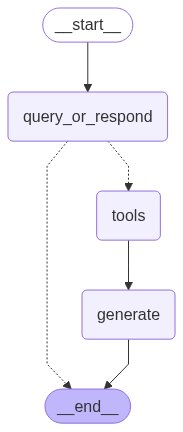

In [16]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
input_message = "Hello" # Defines an input message string that will be sent to the graph.

for step in graph.stream( # Initiates streaming execution of the compiled graph.
    {"messages": [{"role": "user", "content": input_message}]}, # Provides the initial state for the graph, which includes a user message with the defined 'input_message'.
    stream_mode="values", # Specifies that the stream should yield the complete state (values) at each step of the graph's execution.
):
    step["messages"][-1].pretty_print() # For each step (state update) yielded by the stream,
                                       # it accesses the list of messages in the current state (`step["messages"]`)
                                       # takes the last message (`[-1]`), which is typically the most recent output from an LLM or tool,
                                       # and calls its `pretty_print()` method to display it in a human-readable format.

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I help you today?


In [18]:
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?


================================== Ai Message ==================================
Tool Calls:
  retrieve (87935784-3510-44ae-adea-098749f8b02a)
 Call ID: 87935784-3510-44ae-adea-098749f8b02a
  Args:
    query: What is Task Decomposition?
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Yao et al. 2023)

================================== Ai Message ==================================

Task decomposition involves breaking down a complex task into smaller, simpler steps. Chain of Thought (CoT) is a prompting technique that decomposes tasks by instructing the model to "think step by step". Tree of Thoughts extends CoT by exploring multiple reasoning possibilities at each step, creating a tree structure.


In [ ]:
from langgraph.checkpoint.memory import MemorySaver # Imports the 'MemorySaver' class from 'langgraph.checkpoint.memory'.
                                                   # 'MemorySaver' is an in-memory implementation of a checkpointer,
                                                   # used to save and restore the state of a graph's execution,
                                                   # enabling conversational memory and continuation.

memory = MemorySaver() # Initializes an instance of 'MemorySaver'. This object will manage saving and loading graph states in memory.
graph = graph_builder.compile(checkpointer=memory) # Recompiles the previously defined graph, but this time,
                                                   # it integrates the 'memory' (MemorySaver) as a checkpointer.
                                                   # This means the graph will now automatically save its state at various points,
                                                   # allowing for conversational turns and stateful interactions.

# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}} # Defines a configuration dictionary.
                                                 # The "configurable" key allows for dynamic settings.
                                                 # "thread_id": "abc123" assigns a unique identifier to this specific conversation thread.
                                                 # This ID is crucial when using a checkpointer to save and load the state
                                                 # for a particular conversation, ensuring that different conversations
                                                 # don't interfere with each other's memory.

In [ ]:
input_message = "What is Task Decomposition?" # Defines the new user input message for the conversation.

for step in graph.stream( # Initiates a streaming execution of the compiled graph.
    {"messages": [{"role": "user", "content": input_message}]}, # Provides the initial state for this turn, containing the new user message.
    stream_mode="values", # Specifies that the stream should yield complete state values at each step.
    config=config, # Passes the 'config' dictionary, which includes the 'thread_id'. This tells the graph to
                   # use the state associated with "abc123" from the 'MemorySaver' checkpointer, enabling
                   # continuation of the conversation or starting a new one under this ID.
):
    step["messages"][-1].pretty_print() # For each state update yielded by the stream, it accesses the last message
                                       # in the current state and prints it in a user-friendly format.

================================ Human Message =================================

What is Task Decomposition?


================================== Ai Message ==================================
Tool Calls:
  retrieve (1e6a4ddc-2814-4d15-a796-6d2518705b9f)
 Call ID: 1e6a4ddc-2814-4d15-a796-6d2518705b9f
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Yao et al. 2023) extends 

================================== Ai Message ==================================

Task decomposition is a method of breaking down a complex task into smaller, simpler steps. Chain of Thought prompting is a technique that uses task decomposition to enhance model performance on complex tasks. Tree of Thoughts extends this by exploring multiple reasoning possibilities at each step, creating a tree structure.


The provided output demonstrates a multi-step process orchestrated by LangGraph, commonly known as Retrieval-Augmented Generation (RAG). Here's a breakdown of what's happening:

1.  **Human Message Input:**
    * The process begins with a user query: "What is Task Decomposition?"

2.  **AI's Initial Assessment (via `query_or_respond` node):**
    * The AI model (`llm`) first receives the user's question.
    * Instead of attempting to answer directly, it determines that external information is required to provide a comprehensive response.
    * **Action:** The AI generates a `Tool Call` to the `retrieve` tool, specifically requesting information related to "Task Decomposition." This intelligent decision-making is a core feature of tool-calling LLMs.

3.  **Tool Execution (via `tools` node running `retrieve`):**
    * The `retrieve` tool is invoked with "Task Decomposition" as its query argument.
    * This tool performs a similarity search against the `vector_store` (which contains pre-indexed content from the Lilian Weng blog post).
    * **Output:** The `retrieve` tool successfully fetches two relevant document chunks from the blog post. These chunks contain definitions and explanations of "Task Decomposition," "Chain of Thought (CoT)," and "Tree of Thoughts." This retrieved content serves as the factual basis for the subsequent generation step.

4.  **AI's Final Generation (via `generate` node):**
    * The retrieved document content is then provided to the LLM as context within a `SystemMessage`. This contextual information guides the LLM's response.
    * The LLM then synthesizes an answer using the provided context and the original user query.
    * **Output:** The AI generates a concise and informative answer: "Task decomposition is a method of breaking down a complex task into smaller, simpler steps. Chain of Thought prompting is a technique that uses task decomposition to enhance model performance on complex tasks. Tree of Thoughts extends this by exploring multiple reasoning possibilities at each step, creating a tree structure."

**LangSmith Warnings:**
* The `WARNING:langsmith.client:Failed to send compressed multipart ingest: ...` messages indicate issues with sending tracing data to the LangSmith platform. This is typically due to an incorrect, expired, or unauthorized `LANGSMITH_API_KEY`. While these warnings appear, they do not block the core execution flow of the LangGraph application.

**Overall Flow:**
This interaction perfectly illustrates a RAG pipeline:
1.  **Receive Query:** Get the user's question.
2.  **Decide Action:** LLM decides if external tools are needed.
3.  **Retrieve Information:** If needed, a retrieval tool fetches relevant data.
4.  **Generate Response:** LLM uses the retrieved context to formulate an accurate and relevant answer.

This modular approach ensures that the LLM has access to up-to-date and specific information, reducing hallucinations and improving the quality of its responses.

In [21]:
input_message = "Can you look up some common ways of doing it?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Can you look up some common ways of doing it?


================================== Ai Message ==================================
Tool Calls:
  retrieve (a488385e-3fbe-4648-991d-6a7d4d61beba)
 Call ID: a488385e-3fbe-4648-991d-6a7d4d61beba
  Args:
    query: common methods for task decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Yao et

================================== Ai Message ==================================

Chain of Thought (CoT) and Tree of Thoughts are common ways of doing task decomposition. CoT transforms big tasks into multiple manageable tasks. Tree of Thoughts extends CoT by exploring multiple reasoning possibilities at each step, creating a tree structure.


# Agents

Agents leverage the reasoning capabilities of LLMs to make decisions during execution. Using agents allows you to offload additional discretion over the retrieval process. Although their behavior is less predictable than the above "chain", they are able to execute multiple retrieval steps in service of a query, or iterate on a single search.

Agents use LLMs for dynamic decision-making during execution, giving them more control over retrieval. Unlike fixed "chains," agents can perform multiple or iterative searches to fulfill a query. While less predictable, this allows for more adaptable and intelligent information gathering.

In [ ]:
from langgraph.prebuilt import create_react_agent # Imports the `create_react_agent` function from `langgraph.prebuilt`.
                                                   # This function is a convenient utility to quickly set up an agent
                                                   # that uses the ReAct (Reasoning and Acting) framework. ReAct agents
                                                   # reason about what action to take, observe the result, and then repeat.

agent_executor = create_react_agent(llm, [retrieve], checkpointer=memory) # Initializes an agent executor.
                                                                           # `llm`: The Large Language Model (e.g., Gemini-2.0-flash) that will drive the agent's reasoning.
                                                                           # `[retrieve]`: A list of tools that the agent can use. In this case, the agent has access
                                                                           #             to the `retrieve` tool defined earlier for fetching information.
                                                                           # `checkpointer=memory`: Integrates the `memory` (MemorySaver instance) as a checkpointer.
                                                                           #                      This enables the agent to maintain conversational memory and state
                                                                           #                      across multiple interactions, allowing for multi-turn conversations
                                                                           #                      or recovery from interruptions.

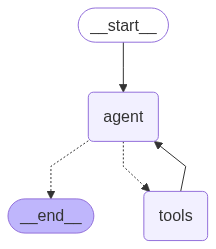

In [23]:
display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "def234"}} # Defines a configuration dictionary for the agent's execution.
                                                 # It sets a new unique 'thread_id' ("def234"). This ensures that
                                                 # this conversation thread maintains its own distinct state and memory
                                                 # separate from any other threads (like "abc123" used previously).

input_message = ( # Defines a multi-line input message for the agent.
    "What is the standard method for Task Decomposition?\n\n" # The first part asks for the standard method.
    "Once you get the answer, look up common extensions of that method." # The second part instructs the agent to
                                                                         # perform a follow-up action based on the first answer,
                                                                         # demonstrating its ability to chain reasoning and actions.
)

for event in agent_executor.stream( # Initiates a streaming execution of the `agent_executor`.
    {"messages": [{"role": "user", "content": input_message}]}, # Provides the initial state to the agent, containing the user's complex query.
    stream_mode="values", # Specifies that the stream should yield the complete state (values) at each step of the agent's execution.
    config=config, # Passes the 'config' dictionary, which includes the new 'thread_id'. This ensures the agent's
                   # memory and state are managed under this specific conversation ID.
):
    event["messages"][-1].pretty_print() # For each event (state update) yielded by the streaming agent,
                                       # it accesses the list of messages in the current state (`event["messages"]`),
                                       # takes the last message (`[-1]`) (which represents the most recent output from the agent's actions or thoughts),
                                       # and calls its `pretty_print()` method to display it in a formatted, human-readable way.

================================ Human Message =================================

What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retrieve (30e3fe3d-4aef-4034-859b-62e18d797e60)
 Call ID: 30e3fe3d-4aef-4034-859b-62e18d797e60
  Args:
    query: standard method for Task Decomposition
================================= Tool Message =================================
Name: retrieve

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to de

================================== Ai Message ==================================

According to the retrieved information, Chain of Thought (CoT) is a standard prompting technique for task decomposition, where the model is instructed to "think step by step" to break down complex tasks into smaller, simpler steps.

Common extensions of this method include:

*   **Tree of Thoughts (ToT)**: This extends CoT by exploring multiple reasoning possibilities at each step, creating a tree structure of thoughts. The search process can be BFS (breadth-first search) or DFS (depth-first search).


Note that the agent:

Generates a query to search for a standard method for task decomposition;

Receiving the answer, generates a second query to search for common extensions of it;

Having received all necessary context, answers the question.